<a href="https://colab.research.google.com/github/dhanalakshminowgotla-hash/Customer--churn--prediction--system-/blob/main/customer_churn_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

# Number of records
n = 3000

# Create dataset
data = {
    "CustomerID": ["CUST" + str(i) for i in range(1, n+1)],
    "Age": np.random.randint(18, 70, n),
    "Gender": np.random.choice(["Male", "Female"], n),
    "SubscriptionType": np.random.choice(["Basic", "Premium", "Enterprise"], n),
    "MonthlyCharges": np.random.randint(300, 5000, n),
    "TenureMonths": np.random.randint(1, 60, n),
    "SupportTickets": np.random.randint(0, 10, n),
    "PaymentMethod": np.random.choice(["Credit Card", "UPI", "Net Banking"], n),
    "SatisfactionScore": np.random.randint(1, 11, n),
    "UsageHoursPerWeek": np.random.randint(1, 50, n),
    "Churn": np.random.choice(["Yes", "No"], n)
}

df = pd.DataFrame(data)

# Show data
df.head()

,CustomerID,Age,Gender,SubscriptionType,MonthlyCharges,TenureMonths,SupportTickets,PaymentMethod,SatisfactionScore,UsageHoursPerWeek,Churn
0,CUST1,48,Male,Basic,4953,4,5,Net Banking,3,26,Yes
1,CUST2,22,Female,Basic,843,19,4,UPI,2,30,No
2,CUST3,68,Female,Enterprise,4766,17,5,Credit Card,10,19,Yes
3,CUST4,26,Male,Enterprise,2168,1,3,UPI,7,47,Yes
4,CUST5,65,Male,Premium,1528,45,1,Credit Card,8,19,No


In [ ]:
import pandas as pd

print(df.head())
print(df.shape)

  CustomerID  Age  Gender SubscriptionType  MonthlyCharges  TenureMonths  \
0      CUST1   48    Male            Basic            4953             4   
1      CUST2   22  Female            Basic             843            19   
2      CUST3   68  Female       Enterprise            4766            17   
3      CUST4   26    Male       Enterprise            2168             1   
4      CUST5   65    Male          Premium            1528            45   

   SupportTickets PaymentMethod  SatisfactionScore  UsageHoursPerWeek Churn  
0               5   Net Banking                  3                 26   Yes  
1               4           UPI                  2                 30    No  
2               5   Credit Card                 10                 19   Yes  
3               3           UPI                  7                 47   Yes  
4               1   Credit Card                  8                 19    No  
(3000, 11)


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style
sns.set_style("white")

In [ ]:
print("Churn Distribution:")
print(df["Churn"].value_counts())

print("\nChurn Percentage:")
print(df["Churn"].value_counts(normalize=True) * 100)

Churn Distribution:
Churn
Yes    1538
No     1462
Name: count, dtype: int64

Churn Percentage:
Churn
Yes    51.266667
No     48.733333
Name: proportion, dtype: float64


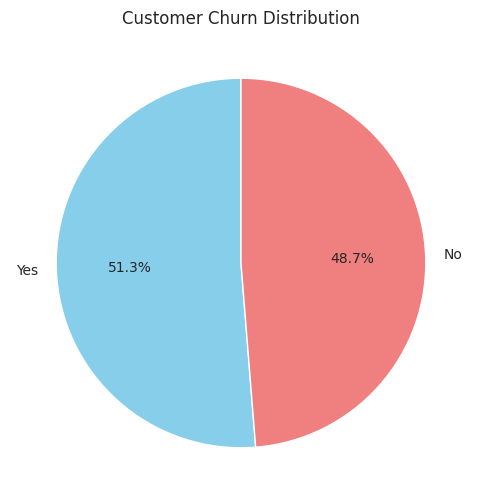

In [ ]:
plt.figure(figsize=(6, 6))

df["Churn"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90,
    colors=['skyblue', 'lightcoral'] # Added custom colors
)

plt.title("Customer Churn Distribution")
plt.ylabel("")
plt.show()

In [ ]:
subscription_churn = pd.crosstab(
    df["SubscriptionType"],
    df["Churn"],
    normalize="index"
) * 100

print(subscription_churn)

Churn                    No        Yes
SubscriptionType                      
Basic             48.787585  51.212415
Enterprise        47.463002  52.536998
Premium           49.853372  50.146628


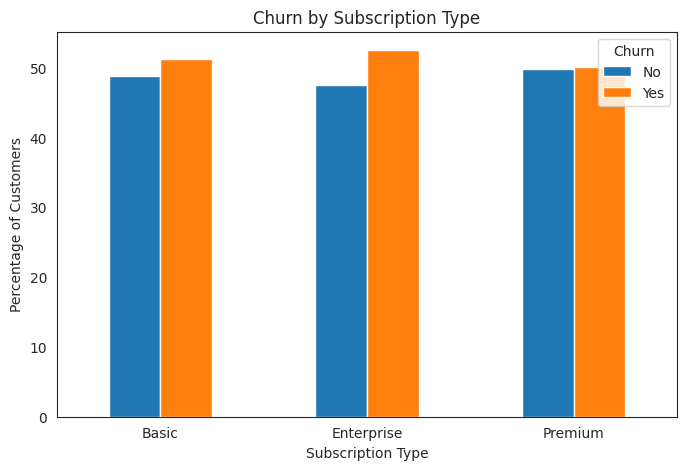

In [ ]:
subscription_churn.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Churn by Subscription Type")
plt.xlabel("Subscription Type")
plt.ylabel("Percentage of Customers")
plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.show()

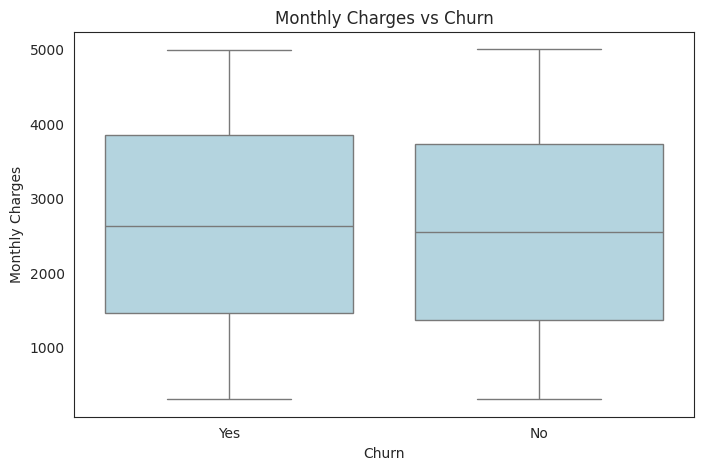

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x="Churn",
    y="MonthlyCharges",
    data=df,
    color='lightblue'
)

plt.title("Monthly Charges vs Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.show()

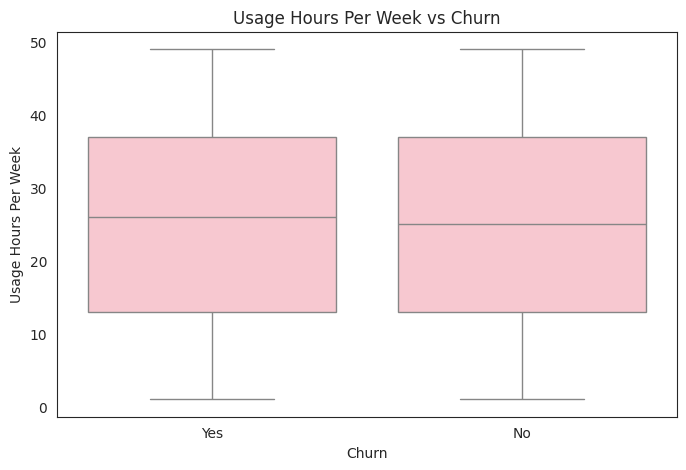

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x="Churn",
    y="UsageHoursPerWeek",
    data=df,
    color='pink'
)

plt.title("Usage Hours Per Week vs Churn")
plt.xlabel("Churn")
plt.ylabel("Usage Hours Per Week")
plt.show()

In [ ]:
print(
    df.groupby("Churn")["SatisfactionScore"].mean()
)

Churn
No     5.471956
Yes    5.516255
Name: SatisfactionScore, dtype: float64


In [ ]:
numeric_data = df.select_dtypes(include="number")

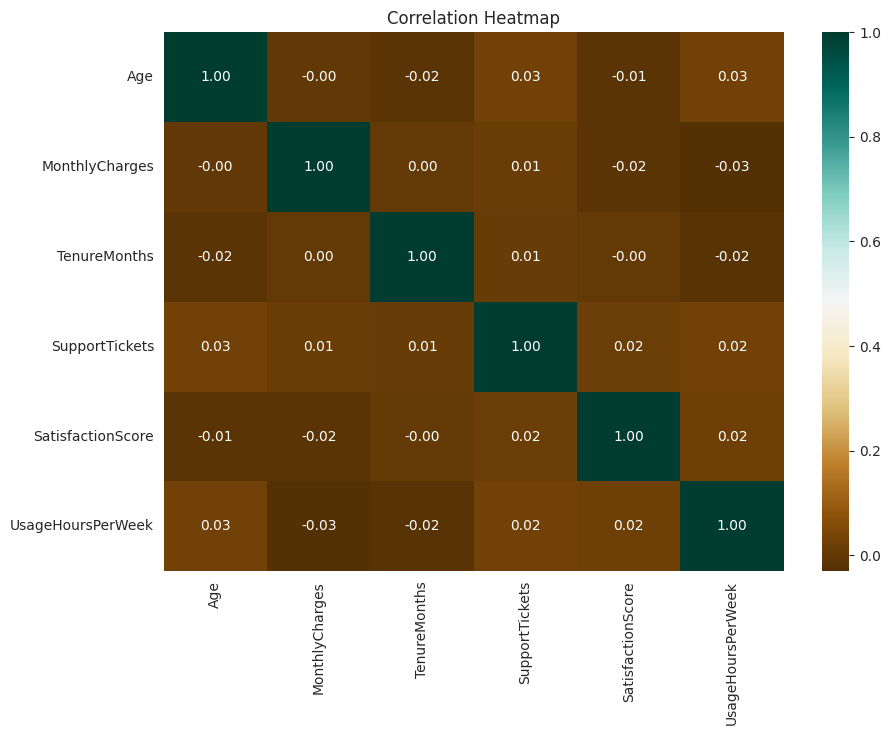

In [ ]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    numeric_data.corr(),
    annot=True,
    cmap="BrBG",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

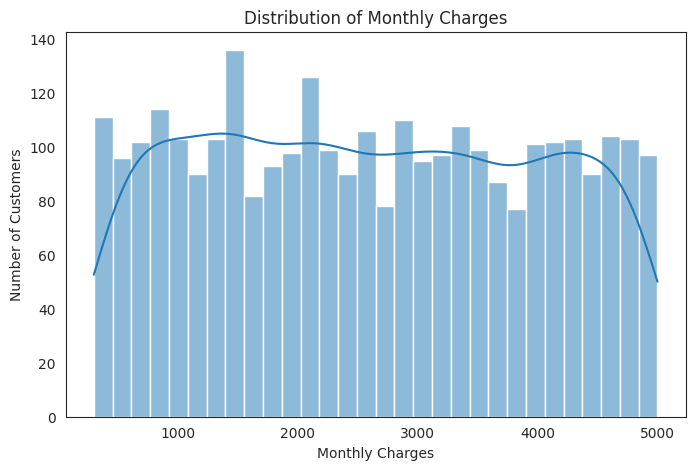

In [ ]:
plt.figure(figsize=(8, 5))

sns.histplot(
    df["MonthlyCharges"],
    bins=30,
    kde=True
)

plt.title("Distribution of Monthly Charges")
plt.xlabel("Monthly Charges")
plt.ylabel("Number of Customers")
plt.show()

In [ ]:
# Separate features and target

X = df.drop("Churn", axis=1)
y = df["Churn"]

print("Feature columns:")
print(X.columns)

print("\nTarget column:")
print(y.name)

Feature columns:
Index(['CustomerID', 'Age', 'Gender', 'SubscriptionType', 'MonthlyCharges',
       'TenureMonths', 'SupportTickets', 'PaymentMethod', 'SatisfactionScore',
       'UsageHoursPerWeek'],
      dtype='object')

Target column:
Churn


In [ ]:
# Remove customer ID

X = X.drop("CustomerID", axis=1)

print("Customer ID removed successfully.")
print(X.head())

Customer ID removed successfully.
   Age  Gender SubscriptionType  MonthlyCharges  TenureMonths  SupportTickets  \
0   48    Male            Basic            4953             4               5   
1   22  Female            Basic             843            19               4   
2   68  Female       Enterprise            4766            17               5   
3   26    Male       Enterprise            2168             1               3   
4   65    Male          Premium            1528            45               1   

  PaymentMethod  SatisfactionScore  UsageHoursPerWeek  
0   Net Banking                  3                 26  
1           UPI                  2                 30  
2   Credit Card                 10                 19  
3           UPI                  7                 47  
4   Credit Card                  8                 19  


In [ ]:
X = pd.get_dummies(
    X,
    columns=["Gender", "SubscriptionType", "PaymentMethod"],
    drop_first=True
)

print("Categorical variables encoded successfully.")
print(X.head())

Categorical variables encoded successfully.
   Age  MonthlyCharges  TenureMonths  SupportTickets  SatisfactionScore  \
0   48            4953             4               5                  3   
1   22             843            19               4                  2   
2   68            4766            17               5                 10   
3   26            2168             1               3                  7   
4   65            1528            45               1                  8   

   UsageHoursPerWeek  Gender_Male  SubscriptionType_Enterprise  \
0                 26         True                        False   
1                 30        False                        False   
2                 19        False                         True   
3                 47         True                         True   
4                 19         True                        False   

   SubscriptionType_Premium  PaymentMethod_Net Banking  PaymentMethod_UPI  
0                     False     

In [ ]:
# Convert target variable into numerical form

y = y.map({
    "No": 0,
    "Yes": 1
})

print(y.value_counts())

Churn
1    1538
0    1462
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training records:", X_train.shape[0])
print("Testing records:", X_test.shape[0])

Training records: 2400
Testing records: 600


In [ ]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

random_forest_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [ ]:
y_pred_rf = random_forest_model.predict(X_test)

print("Random Forest predictions generated successfully!")

Random Forest predictions generated successfully!


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)

print("Random Forest Performance")
print("-------------------------")
print("Accuracy :", round(rf_accuracy, 4))
print("Precision:", round(rf_precision, 4))
print("Recall   :", round(rf_recall, 4))
print("F1 Score :", round(rf_f1, 4))

Random Forest Performance
-------------------------
Accuracy : 0.4883
Precision: 0.5016
Recall   : 0.5195
F1 Score : 0.5104


In [ ]:
!pip install xgboost -q

In [ ]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)

print("XGBoost model trained successfully!")

XGBoost model trained successfully!


In [ ]:
y_pred_xgb = xgb_model.predict(X_test)

print("XGBoost predictions generated successfully!")

XGBoost predictions generated successfully!


In [ ]:
xgb_accuracy = accuracy_score(y_test, y_pred_xgb)
xgb_precision = precision_score(y_test, y_pred_xgb)
xgb_recall = recall_score(y_test, y_pred_xgb)
xgb_f1 = f1_score(y_test, y_pred_xgb)

print("XGBoost Performance")
print("-------------------")
print("Accuracy :", round(xgb_accuracy, 4))
print("Precision:", round(xgb_precision, 4))
print("Recall   :", round(xgb_recall, 4))
print("F1 Score :", round(xgb_f1, 4))

XGBoost Performance
-------------------
Accuracy : 0.4783
Precision: 0.4921
Recall   : 0.5065
F1 Score : 0.4992


In [ ]:
model_comparison = pd.DataFrame({
    "Model": [
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        rf_accuracy,
        xgb_accuracy
    ],
    "Precision": [
        rf_precision,
        xgb_precision
    ],
    "Recall": [
        rf_recall,
        xgb_recall
    ],
    "F1 Score": [
        rf_f1,
        xgb_f1
    ]
})

model_comparison.round(4)

,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest,0.4883,0.5016,0.5195,0.5104
1,XGBoost,0.4783,0.4921,0.5065,0.4992


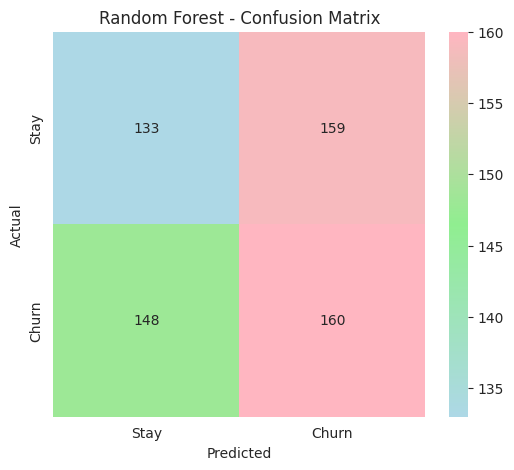

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

cm_rf = confusion_matrix(y_test, y_pred_rf)

# Define the custom colors
colors = ["lightblue", "lightgreen", "lightpink"]
custom_cmap = LinearSegmentedColormap.from_list("mycmap", colors)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    xticklabels=["Stay", "Churn"],
    yticklabels=["Stay", "Churn"],
    cmap=custom_cmap
)

plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

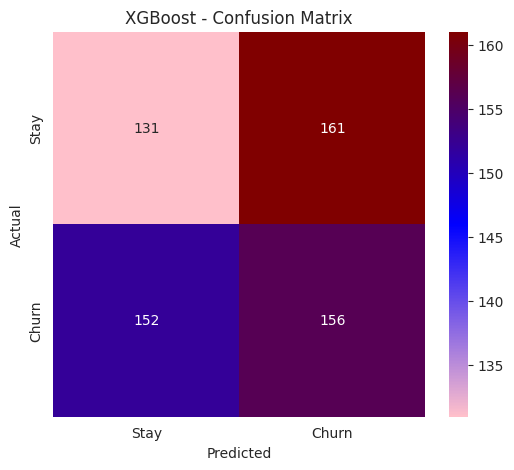

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

cm_xgb = confusion_matrix(y_test, y_pred_xgb)

# Define the custom colors
colors = ["pink", "blue", "maroon"]
custom_cmap = LinearSegmentedColormap.from_list("my_custom_cmap", colors)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_xgb,
    annot=True,
    fmt="d",
    xticklabels=["Stay", "Churn"],
    yticklabels=["Stay", "Churn"],
    cmap=custom_cmap
)

plt.title("XGBoost - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()